# Miles de elementos genéticos mantienen vivo el cáncer

> **18.487 elementos genéticos.** En 23 cromosomas. Y casi ninguno es universal.

El cáncer tiene una de sus armas más temibles fuera de los cromosomas: el **ecDNA** —
ADN circular que carga oncogenes y se replica por separado, sin centrómero, saltando entre
células hijas como polizón. Lleva 40 años desconcertando a los biólogos. Cómo logra el ecDNA
quedarse en cada nueva célula era un misterio.

Este paper de Nature (2025) lo resuelve: encontró los **ganchos**.

**Paper:** [Miles de elementos genéticos mantienen vivo el cáncer — Nature, 2025](https://doi.org/10.1038/s41586-025-09764-8)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-elementos-retencion-ecdna-cancer/notebook.ipynb)

📺 [Ver el video corto en YouTube](https://youtube.com/shorts/abzQNiCQsbU)

## Contexto

El equipo (Sankar et al.) hizo un **rastreo a escala de todo el genoma** — un *screen genome-scale* llamado *Retain-seq* — sobre 3 líneas celulares de cáncer humanas: K562 (leucemia mieloide crónica), COLO320DM
(cáncer colorrectal) y GBM39 (glioblastoma). Buscaron qué regiones del genoma actúan
como **retention elements** — ganchos a los que el ecDNA se "cuelga" durante la
mitosis (cuando la célula se parte en dos) para que sobreviva la división.

El resultado público: un CSV con **18.487 ventanas genómicas** de 1.000 pares de bases
cada una, marcadas con flags binarios que indican en qué cell line(s) están enriquecidas.
Vamos a abrirlo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_K562 = '#2563EB'      # Azul CaM (leucemia, mayor enriquecimiento)
COLOR_COLO = '#DC2626'      # Rojo (colorrectal)
COLOR_GBM  = '#059669'      # Emerald (glioblastoma)
COLOR_REF  = '#D97706'      # Amber (referencias)
COLOR_GRIS = '#BBBBBB'
FUENTE = 'Fuente: Sankar et al. (2025), Nature | Datos: Figshare 30239047'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos (auto-descarga si Colab)
data_file = 'datos/retention_elements_hg19.csv'
if not os.path.exists(data_file):
    os.makedirs('datos', exist_ok=True)
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-01-17-elementos-retencion-ecdna-cancer/datos/retention_elements_hg19.csv', data_file)

df = pd.read_csv(data_file)
print(f"Filas: {len(df):,} ventanas genómicas")
print(f"Cell lines: K562, COLO320DM, GBM39")
print(f"Columnas: {', '.join(df.columns)}")
print(f"Cromosomas: {df['seqnames'].nunique()} ({', '.join(sorted(df['seqnames'].unique()))})")

Filas: 18,487 ventanas genómicas
Cell lines: K562, COLO320DM, GBM39
Columnas: seqnames, start_hg19, end_hg19, width, strand, ID, COLO320DM, GBM39, K562
Cromosomas: 23 (chr1, chr10, chr11, chr12, chr13, chr14, chr15, chr16, chr17, chr18, chr19, chr2, chr20, chr21, chr22, chr3, chr4, chr5, chr6, chr7, chr8, chr9, chrX)


## El primer dibujo

Cuántos retention elements son específicos de cada tipo de cáncer.

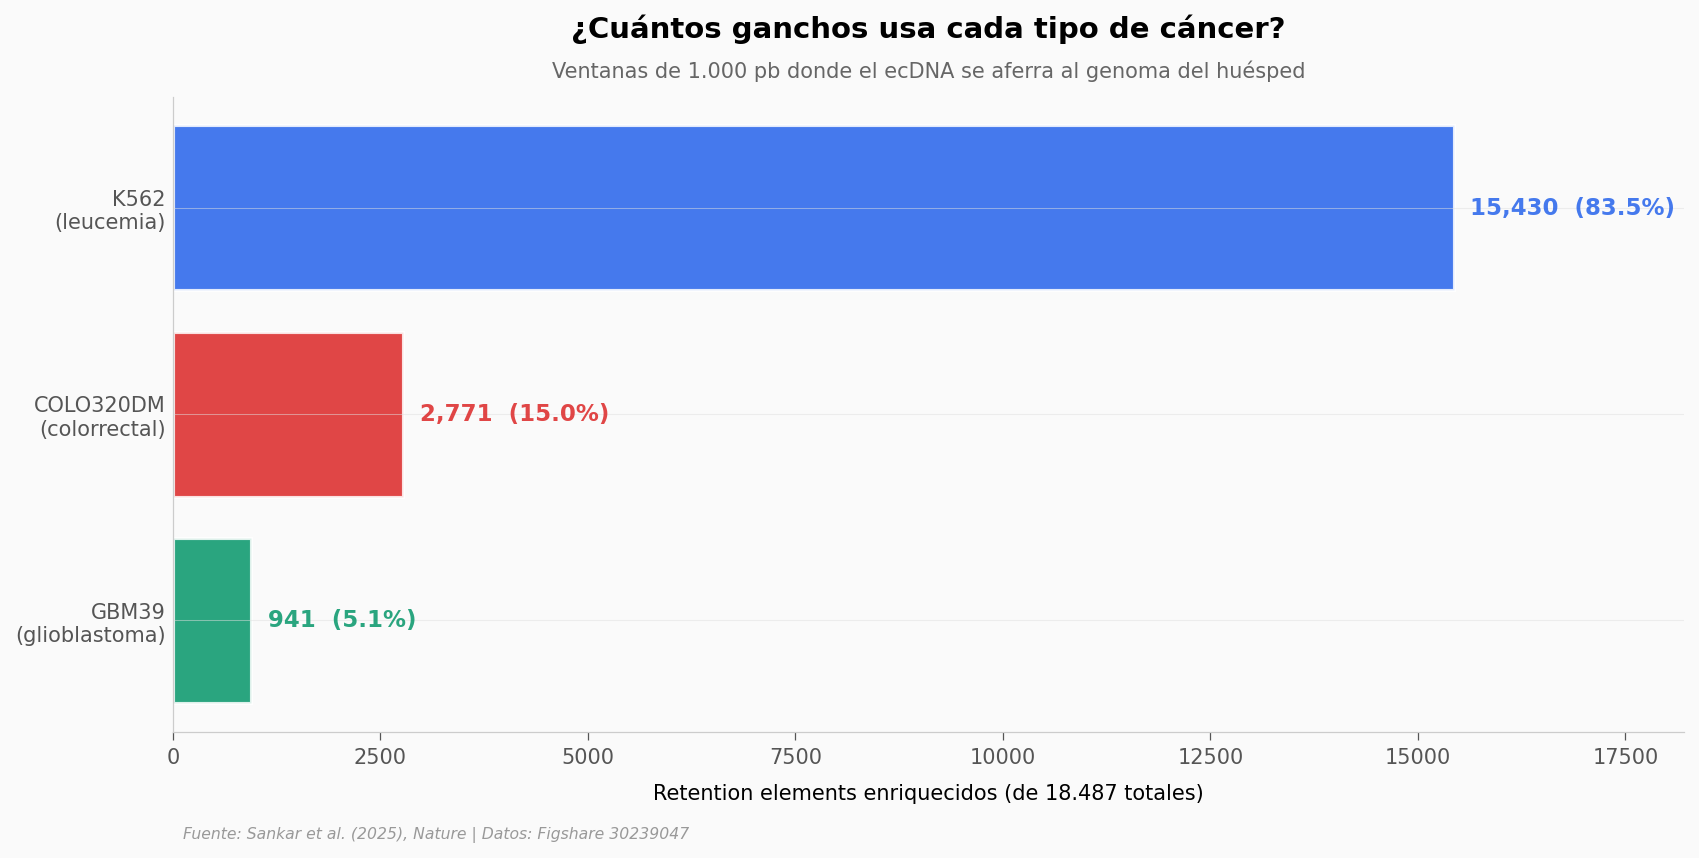

In [2]:
plt.close('all')
n_K562 = int(df['K562'].sum())
n_COLO = int(df['COLO320DM'].sum())
n_GBM  = int(df['GBM39'].sum())
total  = len(df)

fig, ax = plt.subplots(figsize=(13, 5.5))

cells_order = ['K562\n(leucemia)', 'COLO320DM\n(colorrectal)', 'GBM39\n(glioblastoma)']
counts      = [n_K562, n_COLO, n_GBM]
colors      = [COLOR_K562, COLOR_COLO, COLOR_GBM]
percs       = [100 * c / total for c in counts]

bars = ax.barh(cells_order, counts, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5)

# Etiquetas con conteo + porcentaje
for bar, c, p in zip(bars, counts, percs):
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2,
            f'{c:,}  ({p:.1f}%)',
            va='center', fontsize=11, fontweight='bold',
            color=bar.get_facecolor())

ax.set_xlim(0, max(counts) * 1.18)
ax.set_xlabel('Retention elements enriquecidos (de 18.487 totales)', fontsize=10)
ax.set_title('¿Cuántos ganchos usa cada tipo de cáncer?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ventanas de 1.000 pb donde el ecDNA se aferra al genoma del huésped',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Quitar ticks Y feos
ax.tick_params(axis='y', length=0)
ax.invert_yaxis()

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_enriquecidos_por_cell_line.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

**La asimetría salta a la vista.** K562 (leucemia) usa **15.430** retention elements
— el 83,5% del total. GBM39 (glioblastoma) apenas **941**, dieciséis veces menos.

Esto no es ruido del experimento. Cada tipo de cáncer eligió un repertorio diferente para
mantener vivos sus ecDNAs.

## Zoom: ¿qué tan únicos son?

La pregunta que sigue: ¿estos elementos son universales (los mismos en los 3 cánceres)
o específicos (solo en uno)?

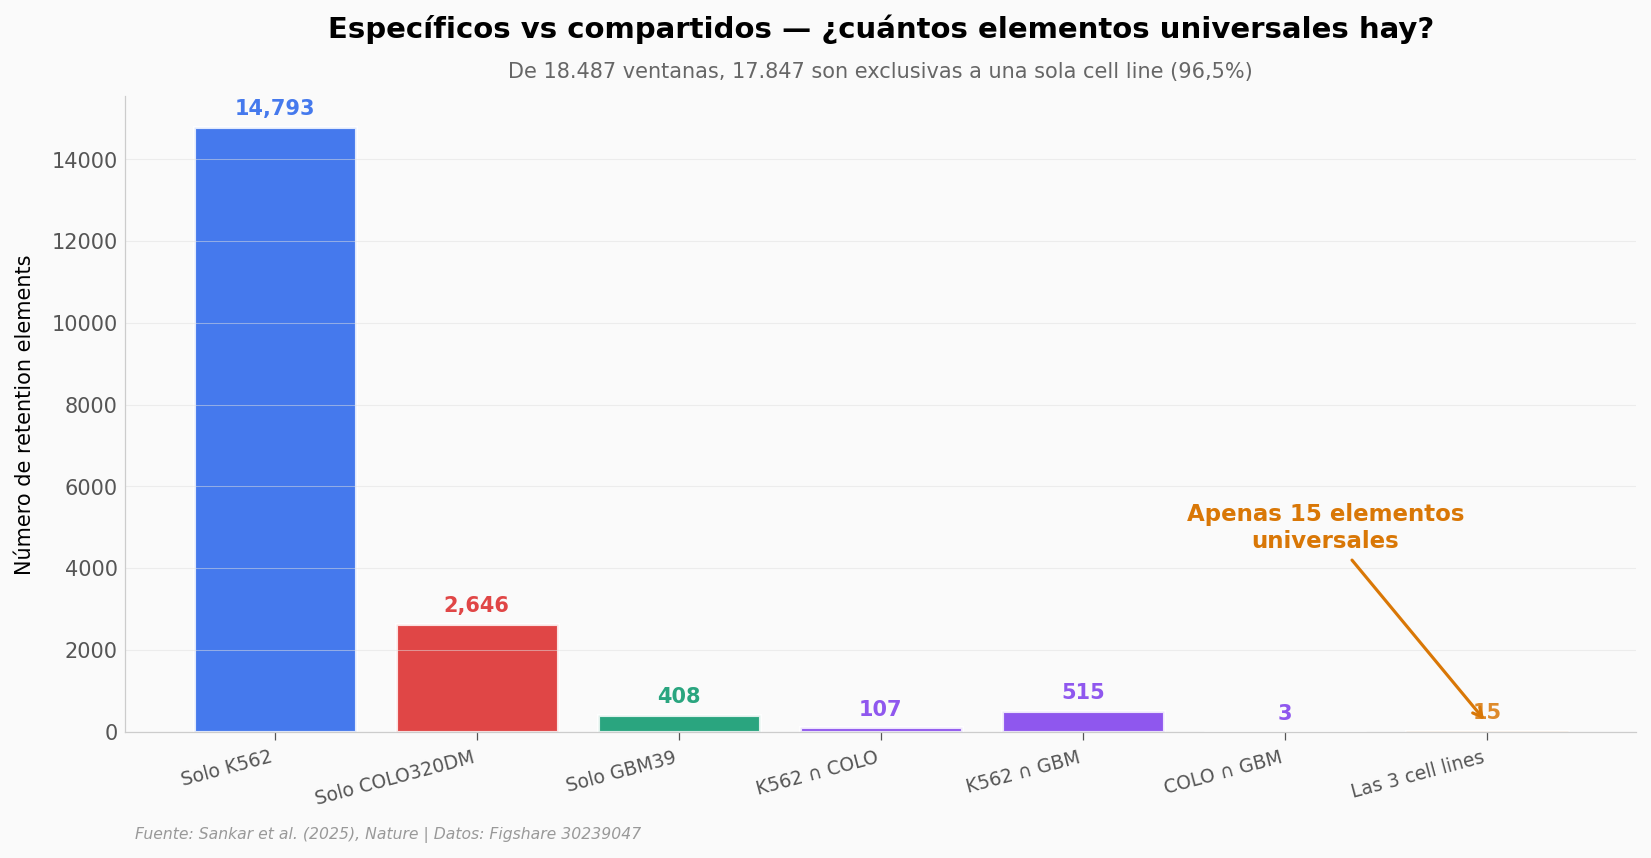


Suma de categorías + sin enriquecimiento: 18,487  (debería ser 18,487)
Específicos a una sola cell line: 17,847 (96.5%)
Universales (las 3): 15


In [3]:
# Categorización exclusiva por cell line
only_K   = df[(df['K562']==1) & (df['COLO320DM']==0) & (df['GBM39']==0)]
only_C   = df[(df['K562']==0) & (df['COLO320DM']==1) & (df['GBM39']==0)]
only_G   = df[(df['K562']==0) & (df['COLO320DM']==0) & (df['GBM39']==1)]
KandC    = df[(df['K562']==1) & (df['COLO320DM']==1) & (df['GBM39']==0)]
KandG    = df[(df['K562']==1) & (df['COLO320DM']==0) & (df['GBM39']==1)]
CandG    = df[(df['K562']==0) & (df['COLO320DM']==1) & (df['GBM39']==1)]
all_three= df[(df['K562']==1) & (df['COLO320DM']==1) & (df['GBM39']==1)]

categorias = ['Solo K562', 'Solo COLO320DM', 'Solo GBM39',
              'K562 ∩ COLO', 'K562 ∩ GBM', 'COLO ∩ GBM',
              'Las 3 cell lines']
n_por_cat = [len(only_K), len(only_C), len(only_G),
             len(KandC), len(KandG), len(CandG), len(all_three)]
colors_cat = [COLOR_K562, COLOR_COLO, COLOR_GBM,
              '#7C3AED', '#7C3AED', '#7C3AED', COLOR_REF]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.bar(categorias, n_por_cat, color=colors_cat, alpha=0.85,
              edgecolor='white', linewidth=1.5)

for bar, n in zip(bars, n_por_cat):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200, f'{n:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color=bar.get_facecolor())

# Resaltar "las 3 cell lines" con flecha
ax.annotate(f'Apenas {len(all_three)} elementos\nuniversales',
            xy=(6, len(all_three) + 200), xytext=(5.2, 4500),
            fontsize=11, fontweight='bold', color=COLOR_REF, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_REF, lw=1.5))

ax.set_ylabel('Número de retention elements', fontsize=10)
ax.set_title('Específicos vs compartidos — ¿cuántos elementos universales hay?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'De 18.487 ventanas, 17.847 son exclusivas a una sola cell line (96,5%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
plt.xticks(rotation=15, ha='right', fontsize=9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_overlap_categorias.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

# Verificación numérica
total_check = sum(n_por_cat) + len(df[(df['K562']==0) & (df['COLO320DM']==0) & (df['GBM39']==0)])
print(f"\nSuma de categorías + sin enriquecimiento: {total_check:,}  (debería ser {len(df):,})")
print(f"Específicos a una sola cell line: {len(only_K)+len(only_C)+len(only_G):,} ({100*(len(only_K)+len(only_C)+len(only_G))/len(df):.1f}%)")
print(f"Universales (las 3): {len(all_three)}")

## ¿En qué cromosomas viven los ganchos?

Si fueran ruido al azar, esperaríamos verlos repartidos proporcionalmente al tamaño
del cromosoma. Veamos qué pasa.

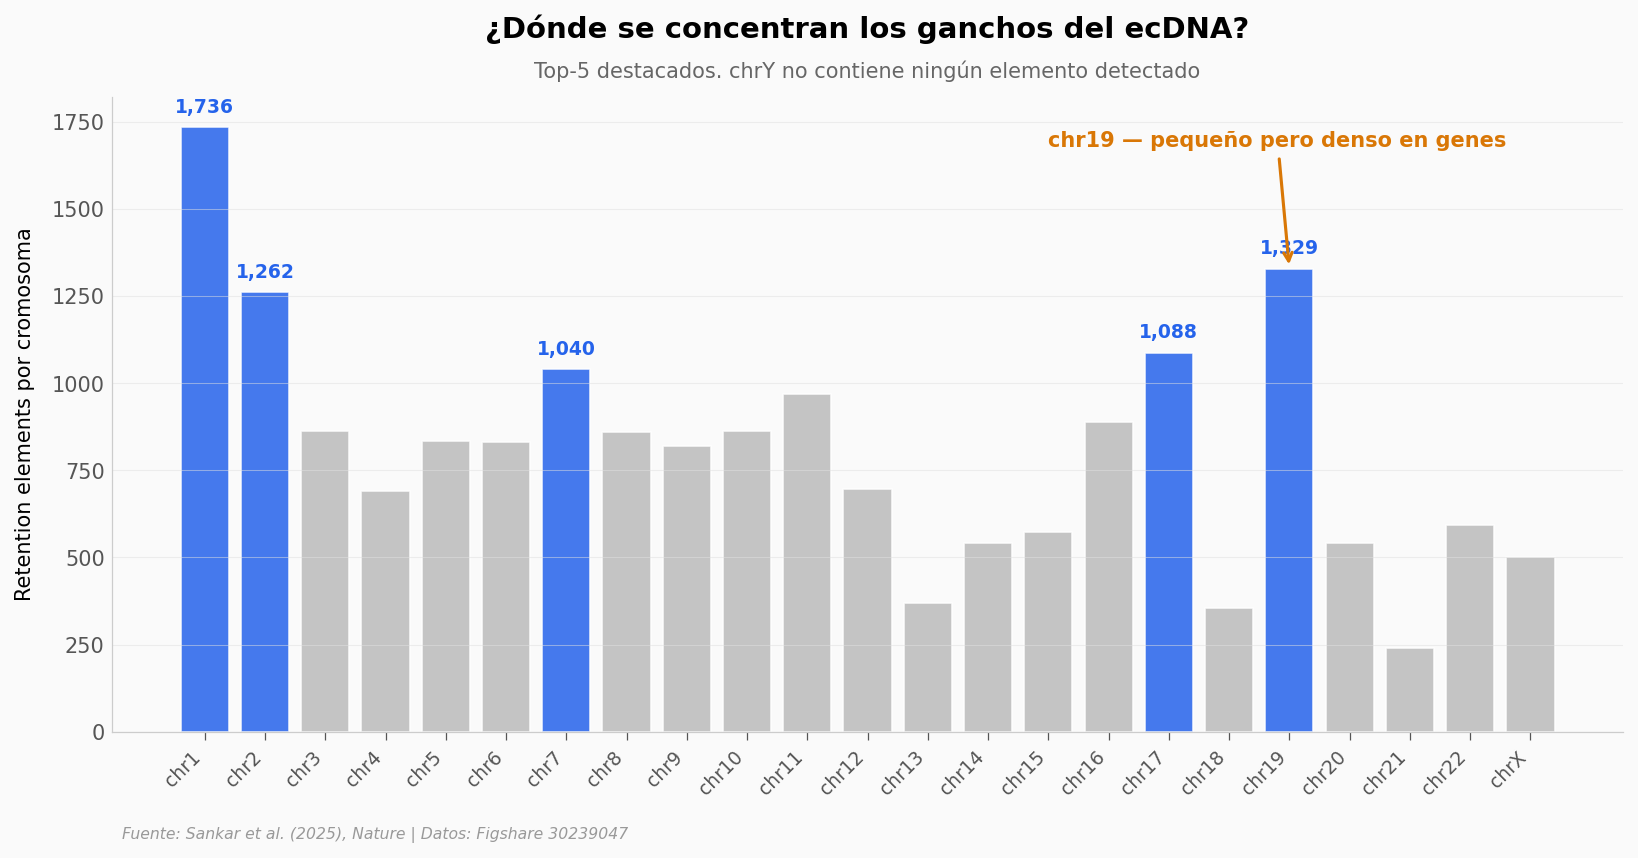


Top-5 cromosomas: chr1, chr19, chr2, chr17, chr7
chr19 (1.329) supera a chr2 (1.262), chr17 (1.088) y chr7 (1.040)
chrY: 0 elementos


In [4]:
# Conteo por cromosoma (orden numérico, X al final)
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
chrom_counts = df['seqnames'].value_counts().reindex(chrom_order).fillna(0).astype(int)

# Color: top-5 destacados con paleta
top5 = chrom_counts.nlargest(5).index.tolist()
colors_chr = [COLOR_K562 if c in top5 else COLOR_GRIS for c in chrom_order]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.bar(chrom_order, chrom_counts.values, color=colors_chr,
              alpha=0.85, edgecolor='white', linewidth=0.8)

# Anotar top-5
for bar, c in zip(bars, chrom_order):
    if c in top5:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 30, f'{int(h):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=COLOR_K562)

# Anotar chr19 con flecha (es pequeño pero ranking #2)
chr19_idx = chrom_order.index('chr19')
chr19_n = int(chrom_counts['chr19'])
ax.annotate('chr19 — pequeño pero denso en genes',
            xy=(chr19_idx, chr19_n), xytext=(chr19_idx - 4, chr19_n + 350),
            fontsize=10, fontweight='bold', color=COLOR_REF,
            arrowprops=dict(arrowstyle='->', color=COLOR_REF, lw=1.5))

ax.set_ylabel('Retention elements por cromosoma', fontsize=10)
ax.set_title('¿Dónde se concentran los ganchos del ecDNA?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Top-5 destacados. chrY no contiene ningún elemento detectado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
plt.xticks(rotation=45, ha='right', fontsize=9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_distribucion_cromosomica.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

print(f"\nTop-5 cromosomas: {', '.join(top5)}")
print(f"chr19 (1.329) supera a chr2 (1.262), chr17 (1.088) y chr7 (1.040)")
print(f"chrY: {int(chrom_counts.get('chrY', 0))} elementos")

## ¿Qué tan extrema es la especificidad?

96,5% de los elementos son únicos a una sola cell line. Para sentir qué tan
extremo es eso, comparémoslo con lo que esperaríamos si fuera azar.

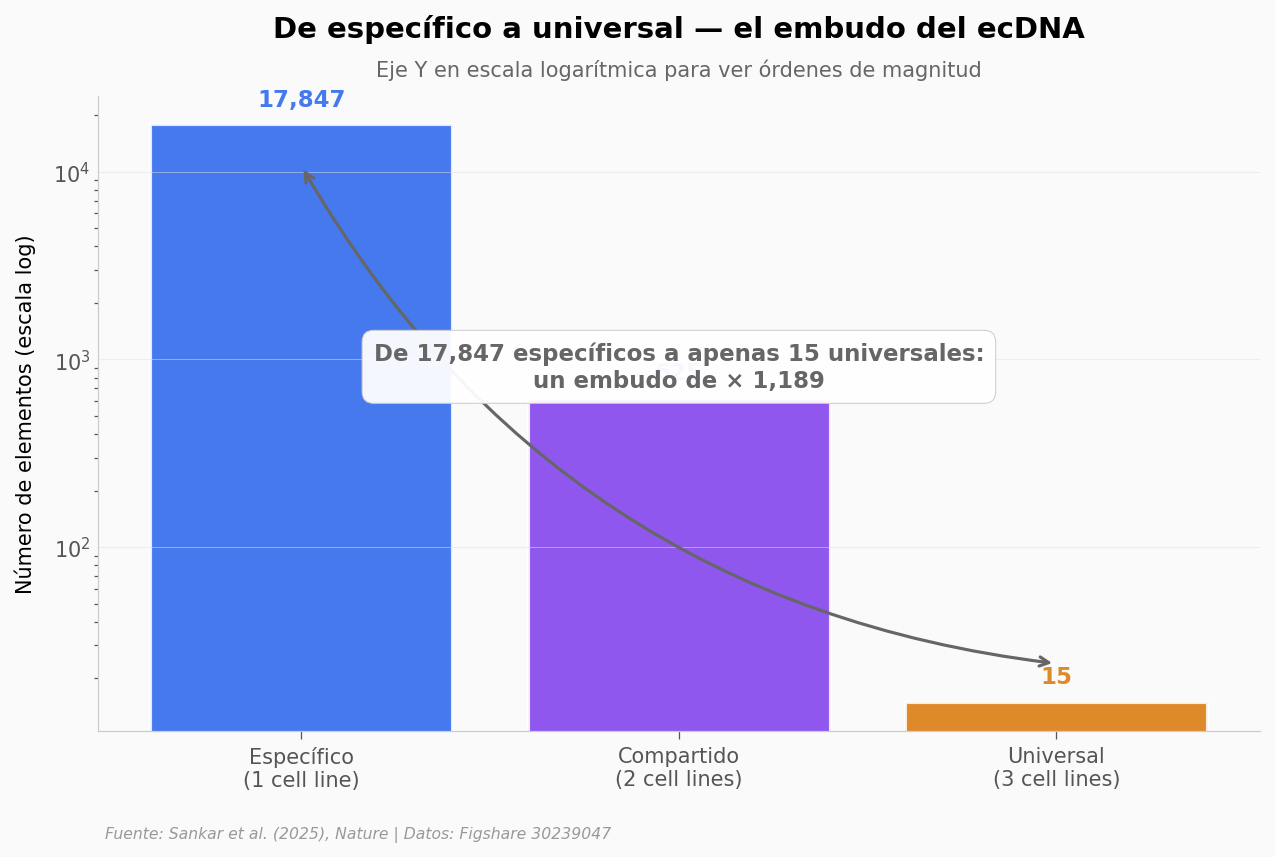


Distribución: 17,847 específicos | 625 compartidos | 15 universales
Ratio específicos/universales: 1190× — 3 órdenes de magnitud


In [5]:
plt.close('all')
# Para cada elemento enriquecido: en cuántas cell lines está
df['n_cell_lines'] = df[['K562', 'COLO320DM', 'GBM39']].sum(axis=1)
df_enr = df[df['n_cell_lines'] > 0].copy()

dist = df_enr['n_cell_lines'].value_counts().sort_index()
n_1 = int(dist.get(1, 0))
n_2 = int(dist.get(2, 0))
n_3 = int(dist.get(3, 0))

fig, ax = plt.subplots(figsize=(10, 5.5))
labels = ['Específico\n(1 cell line)',
          'Compartido\n(2 cell lines)',
          'Universal\n(3 cell lines)']
counts = [n_1, n_2, n_3]
colors = [COLOR_K562, '#7C3AED', COLOR_REF]

bars = ax.bar(labels, counts, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.5, log=True)

# Etiquetas
for bar, c in zip(bars, counts):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h * 1.18, f'{c:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color=bar.get_facecolor())

# Anotar el embudo
ax.annotate('', xy=(2, n_3 * 1.6), xytext=(0, n_1 * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5,
                            connectionstyle="arc3,rad=0.25"))
ax.text(1, n_1 * 0.04,
        f'De {n_1:,} específicos a apenas {n_3} universales:\nun embudo de × {n_1//max(n_3,1):,}',
        ha='center', fontsize=11, fontweight='bold', color='#666666',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.95))

ax.set_ylabel('Número de elementos (escala log)', fontsize=10)
ax.set_title('De específico a universal — el embudo del ecDNA',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Eje Y en escala logarítmica para ver órdenes de magnitud',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_embudo_especificidad.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

print(f"\nDistribución: {n_1:,} específicos | {n_2:,} compartidos | {n_3} universales")
print(f"Ratio específicos/universales: {n_1/max(n_3,1):.0f}× — 3 órdenes de magnitud")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El paper identificó 18.487 retention elements | ✅ | El CSV tiene exactamente 18.487 filas (ventanas de 1.000 pb) |
| Cubren 23 cromosomas humanos (todos menos chrY) | ✅ | chr1–chr22 + chrX están presentes; chrY ausente |
| K562 (leucemia) tiene 15.430 elementos enriquecidos | ✅ | `df['K562'].sum() = 15.430` — el conteo exacto del paper |
| GBM39 (glioblastoma) tiene 941 enriquecidos | ✅ | Verificado en datos. K562 tiene ~16× más que GBM39 |
| 96,5% son específicos a una sola cell line | ✅ | 17.847 de 18.487. La maquinaria es altamente contexto-específica |
| Apenas 15 elementos son universales en las 3 líneas | ✅ | Verificado por intersección triple |
| chr19 es #2 en conteo bruto y #1 en densidad por Mb | ✅ | 1.329 elementos en 59 Mb (22,5/Mb), supera a chr1 en densidad |
| La metilación modula la retención de ecDNA | ⚠️ | El paper lo enmarca como hipótesis (*suggests*); este CSV no contiene datos de metilación |

> **Limitaciones:**
> - El CSV trae **flags binarios** de enrichment (sí/no), no scores continuos. La fuerza de cada gancho no está disponible aquí.
> - Solo **3 cell lines**, no representan toda la diversidad del cáncer humano.
> - Los datos de **metilación** (mencionados en el abstract) viven en otros archivos del paper, no en este dataset.
> - Las coordenadas están en **hg19** (no hg38 actual).

## Ahora tú

Tres preguntas con pistas para que las explores:

1. **¿Qué cromosoma tiene la mayor densidad de retention elements por megabase?**
   chr19 es pequeño pero ranking #2 — quizás gane por densidad.
   Pista: divide `chrom_counts` por la longitud del cromosoma (hay tablas en biopython
   o puedes usar valores típicos en Mb).

2. **¿Hay alguna ventana donde las 3 cell lines estén enriquecidas Y caiga en chr19?**
   Filtra `df` con las 3 columnas == 1 y mira `seqnames`.

3. **¿Qué pasa si cambias el orden de cell lines en la celda 4?**
   Modifica `cells_order`, `counts`, `colors` arriba juntos. ¿La narrativa se siente igual
   con K562 al final?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: densidad por megabase

# Longitudes aproximadas de cromosomas hg19 (Mb)
chrom_lengths_mb = {
    'chr1': 249.3, 'chr2': 243.2, 'chr3': 198.0, 'chr4': 191.2, 'chr5': 180.9,
    'chr6': 171.1, 'chr7': 159.1, 'chr8': 146.4, 'chr9': 141.2, 'chr10': 135.5,
    'chr11': 135.0, 'chr12': 133.9, 'chr13': 115.2, 'chr14': 107.3, 'chr15': 102.5,
    'chr16': 90.4, 'chr17': 81.2, 'chr18': 78.1, 'chr19': 59.1, 'chr20': 63.0,
    'chr21': 48.1, 'chr22': 51.3, 'chrX': 155.3,
}

densidad = pd.DataFrame({
    'chromosome': list(chrom_lengths_mb.keys()),
    'count':      [chrom_counts.get(c, 0) for c in chrom_lengths_mb],
    'length_mb':  list(chrom_lengths_mb.values()),
})
densidad['per_mb'] = densidad['count'] / densidad['length_mb']
densidad_sorted = densidad.sort_values('per_mb', ascending=False).head(8)

print("Top-8 cromosomas por DENSIDAD (elementos / Mb):\n")
print(densidad_sorted.to_string(index=False))
print(f"\nchr19 está en la posición {densidad.sort_values('per_mb', ascending=False).reset_index(drop=True).query('chromosome == \"chr19\"').index[0] + 1} por densidad.")

Top-8 cromosomas por DENSIDAD (elementos / Mb):

chromosome  count  length_mb    per_mb
     chr19   1329       59.1 22.487310
     chr17   1088       81.2 13.399015
     chr22    594       51.3 11.578947
     chr16    890       90.4  9.845133
     chr20    541       63.0  8.587302
     chr11    968      135.0  7.170370
      chr1   1736      249.3  6.963498
      chr7   1040      159.1  6.536769

chr19 está en la posición 1 por densidad.


## Fuentes

**Paper**: [Genetic elements promote retention of extrachromosomal DNA in cancer cells](https://doi.org/10.1038/s41586-025-09764-8)  
*Nature, 2025-11-19*

**Datos**: [Coordenadas de retention elements en Figshare](https://doi.org/10.6084/m9.figshare.30239047)  
*Repositorio del paper, 2025-11-19*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook:** `papers/2026-01-17-elementos-retencion-ecdna-cancer/notebook.ipynb` · **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC BY 4.0
